1. How many cells are significantly tuned to escape route in each condition across all sessions?
2. How many cells are sig. tuned to shelter distance in each condition across all sessions?
3. How many cells are tuned to more than one variable and/or more than one condition?
4. Comparing the tuning across conditions for cells tuned in multiple conditions

In [116]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, #JAL6_flip5_25mar, (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may] # JAL8_flip4_10may,

session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", # "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may"] # "JAL8_flip4_10may",

In [2]:
%load_ext autoreload
from behave_analysis.process.process import Process
from behave_analysis.utils.creating_directories import make_directory

import os
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from pathlib import Path
import dill as pickle
from itertools import product

%matplotlib inline

In [118]:
"""Load in data from homing/escape analysis"""
%autoreload 2

compression = ['bird_dist_shelter', 'full_distance_shelter', 'escape']

c_names = ['shelter_only', 'barrier', 'flipped_barrier']

full_dict = {}
sig_cell_dict = {}

for comp in compression:

    # print(comp)

    full_dict[comp] = {'shelter_only': [],
                        'barrier': [],
                        'flipped_barrier': []}
    
    sesh_names = []
    all_sig_cells = []

    for exp in experiments_objects:

        # print(exp.nick_name + '_' + exp.experiment_date)

        # load data
        nickname = exp.nick_name + '_' + exp.experiment_date
        sesh_names.append(nickname)
        exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp

        dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname)
        saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
        data = np.load(saving_file)

        # pull out the paramas
        data_files = data.files
        if 'params_real' in data_files:
            params_real = data['params_real']
            params_shifts = data['params_shifts']
        else:
            params_real = data["arr_12"]
            params_shifts = data["arr_1"]
        
        # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
        sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)
        if len(all_sig_cells) == 0:
            all_sig_cells = sig_cells
            sesh_vector = np.ones(sig_cells.shape[0])
        else:
            all_sig_cells = np.vstack((all_sig_cells, sig_cells))
            sesh_vector = np.hstack((sesh_vector, np.ones(sig_cells.shape[0]) * (sesh_vector[-1]+1)))

        for c in range(sig_cells.shape[1]):
            full_dict[comp][c_names[c]].append(np.sum(sig_cells[:,c])/sig_cells.shape[0])
    
    sig_cell_dict[comp] = all_sig_cells


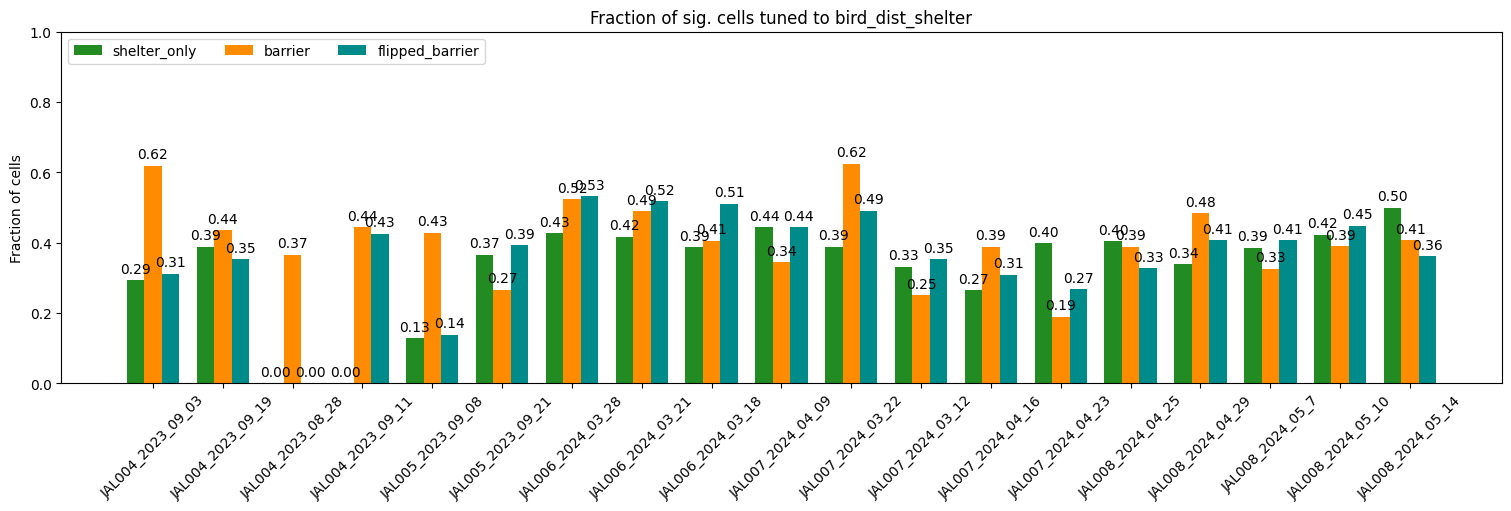

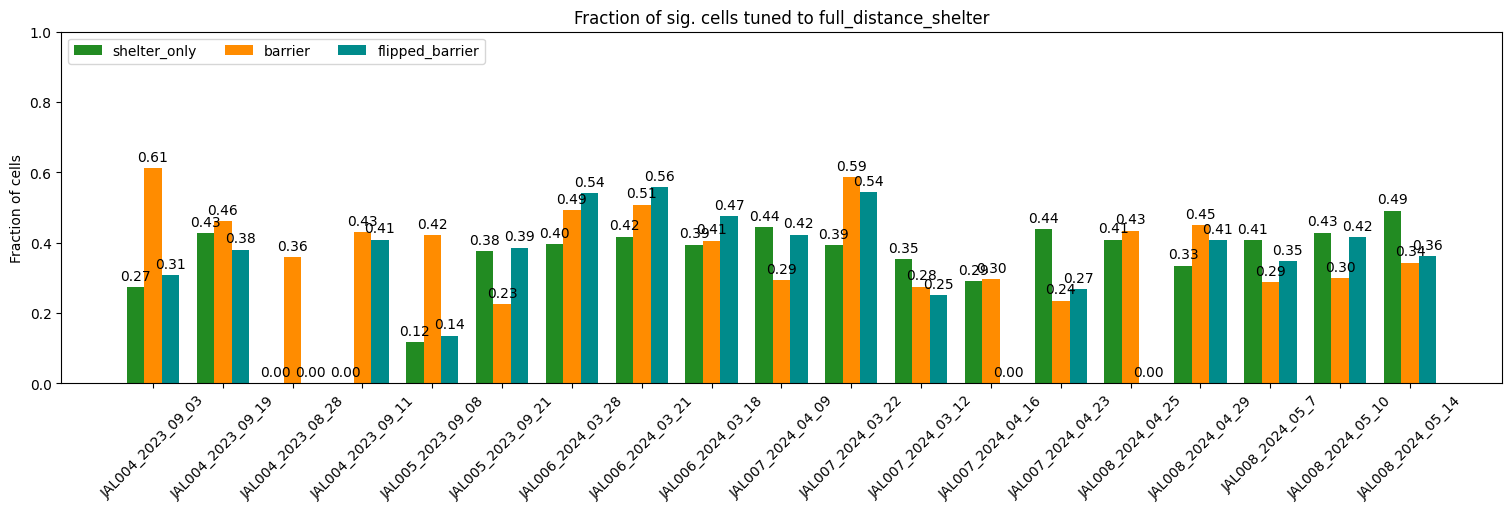

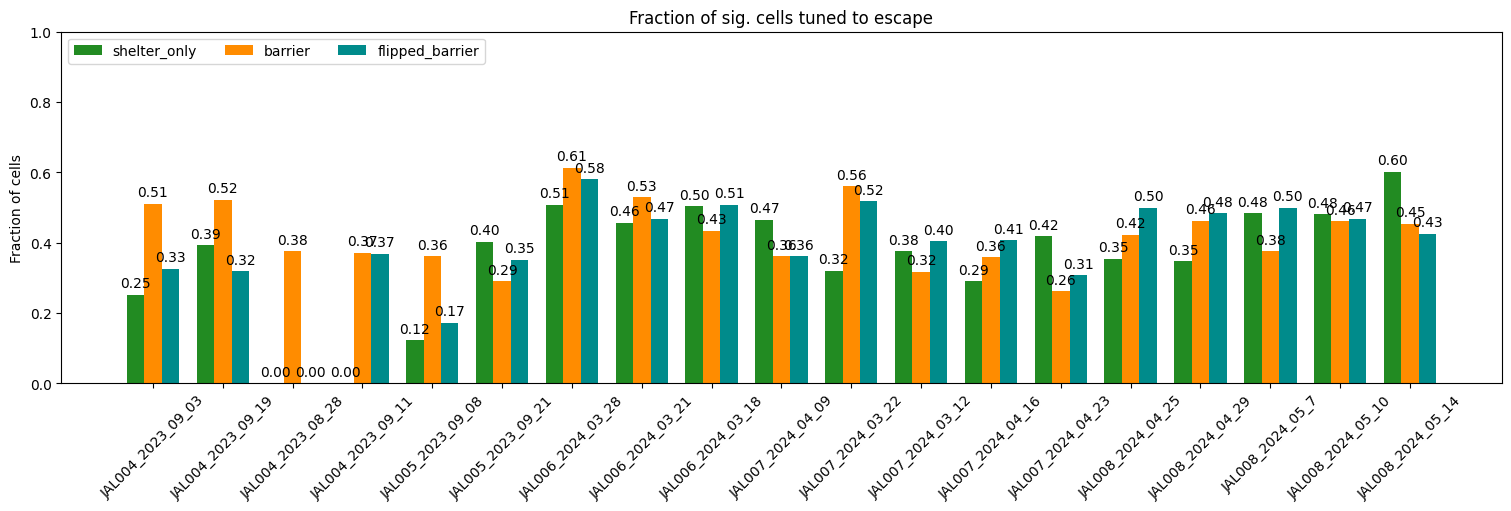

In [105]:
"""Make grouped bar plot of the fraction of cells significantly tuned to each compression var"""
x = np.arange(len(sesh_names))  # the label locations
width = 0.25  # the width of the bars
colors = ['#228B22','#FF8C00','#008B8B']
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves" )

for comp in compression:
    fig, ax = plt.subplots(figsize = (15,5), layout='constrained')

    # Loop through conditions and plot bars
    multiplier = 0
    for idx, (attribute, measurement) in enumerate(full_dict[comp].items()):
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=colors[idx])  # Set custom colors
        ax.bar_label(rects, fmt="%.2f", padding=3)  # Format labels to two decimal places
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Fraction of cells')
    ax.set_title('Fraction of sig. cells tuned to ' + comp)
    ax.set_xticks(x + width, sesh_names, rotation = 45)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

    # plt.show()
    fig.savefig(dump_path + "/fraction_sig_" + comp +".png")
    # plt.close()

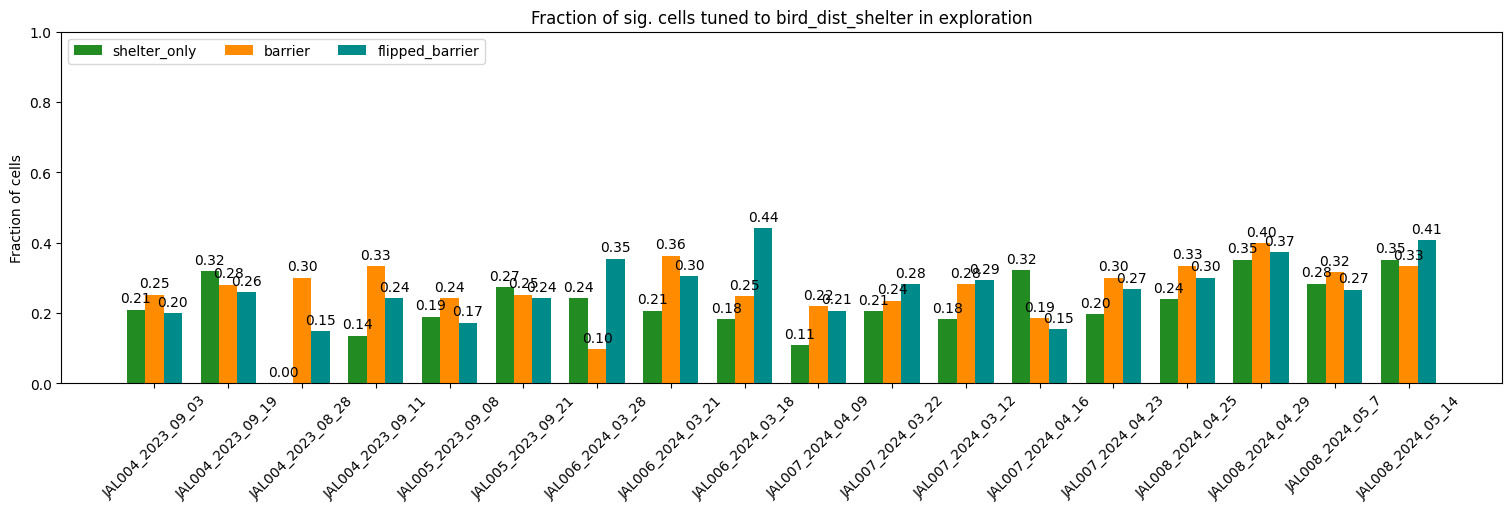

In [128]:
"""Compare to tuning to shelter distance (bird's flight) in exploration"""
"""Load in data from explore analysis"""
%autoreload 2

compression = ['bird_dist_shelter']

c_names = ['shelter_only', 'barrier', 'flipped_barrier']

exp_full_dict = {}
exp_sig_cell_dict = {}

for comp in compression:

    # print(comp)

    exp_full_dict[comp] = {'shelter_only': [],
                        'barrier': [],
                        'flipped_barrier': []}
    
    exp_sesh_names = []
    exp_all_sig_cells = []

    for exp in experiments_objects:

        # print(exp.nick_name + '_' + exp.experiment_date)

        # load data
        nickname = exp.nick_name + '_' + exp.experiment_date
        exp_sesh_names.append(nickname)
        exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp

        dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/" + nickname)
        saving_file = dump_path + exp_nickname + '_Tuning.npz'
        data = np.load(saving_file)

        # pull out the paramas
        data_files = data.files
        if 'params_real' in data_files:
            params_real = data['params_real']
            params_shifts = data['params_shifts']
        else:
            params_real = data["arr_12"]
            params_shifts = data["arr_1"]
        
        # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
        exp_sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)
        if len(exp_all_sig_cells) == 0:
            exp_all_sig_cells = exp_sig_cells
            exp_sesh_vector = np.ones(exp_sig_cells.shape[0])
        else:
            exp_all_sig_cells = np.vstack((exp_all_sig_cells, exp_sig_cells))
            exp_sesh_vector = np.hstack((exp_sesh_vector, np.ones(exp_sig_cells.shape[0]) * (exp_sesh_vector[-1]+1)))

        for c in range(exp_sig_cells.shape[1]):
            exp_full_dict[comp][c_names[c]].append(np.sum(exp_sig_cells[:,c])/exp_sig_cells.shape[0])
    
    exp_sig_cell_dict[comp] = exp_all_sig_cells


"""Make grouped bar plot of the fraction of cells significantly tuned to each compression var"""
x = np.arange(len(sesh_names))  # the label locations
width = 0.25  # the width of the bars
colors = ['#228B22','#FF8C00','#008B8B']
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves" )

for comp in compression:
    fig, ax = plt.subplots(figsize = (15,5), layout='constrained')

    # Loop through conditions and plot bars
    multiplier = 0
    for idx, (attribute, measurement) in enumerate(exp_full_dict[comp].items()):
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=colors[idx])  # Set custom colors
        ax.bar_label(rects, fmt="%.2f", padding=3)  # Format labels to two decimal places
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Fraction of cells')
    ax.set_title('Fraction of sig. cells tuned to ' + comp + ' in exploration')
    ax.set_xticks(x + width, sesh_names, rotation = 45)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

    # plt.show()
    fig.savefig(dump_path + "/fraction_sig_exp_" + comp +".png")
    # plt.close()

In [120]:
"""Load in hdir cells"""
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
with open(dir, "rb") as dill_file:
    hdir = pickle.load(dill_file)

"""Compare to hdir"""

for idx, exp in enumerate(experiments_objects):
    if np.sum(sesh_vector == (idx+1)) > 0:
            # load in cluster Ids
        session = Process(exp).load_session()
        base_path = os.path.join(session.base_path, session.processed_path)
        clu_Ids = np.load(os.path.join(session.base_path, session.processed_path)
            + "\\"
            + "good_cluster_Ids.npy"
        )

        # double check that it is the same length as the one we got from 
        if len(clu_Ids) == np.sum(sesh_vector == (idx+1)):
            # make a zeros vector of n_neur, make hdirs 1s
            sesh_hdir = np.zeros(len(clu_Ids))
            # find the name of the dict key, and which ones are the hdir cells
            hdir_n = hdir[session_names[idx]]
            hdir_idx = [int(np.where(clu_Ids == int(x))[0][0]) for x in hdir_n]
            sesh_hdir[hdir_idx] = 1
            # save the hdir vector and the session id vector
            if idx == 0:
                hdir_sesh_vector = np.ones(len(clu_Ids))
                all_sesh_hdir = sesh_hdir
            else:
                hdir_sesh_vector = np.hstack((hdir_sesh_vector, np.ones(len(clu_Ids)) * (idx+1)))
                all_sesh_hdir = np.hstack((all_sesh_hdir, sesh_hdir))
        else:
            print('This session has unmatched number of neurons: ' + session_names[idx])
    else:
            print('This session is empty: ' + session_names[idx])

print(len(all_sesh_hdir), len(hdir_sesh_vector), len(sesh_vector), np.shape(sig_cell_dict[comp]))

4273 4273 4273 (4273, 3)


Compare significantly tuned cells to hdir

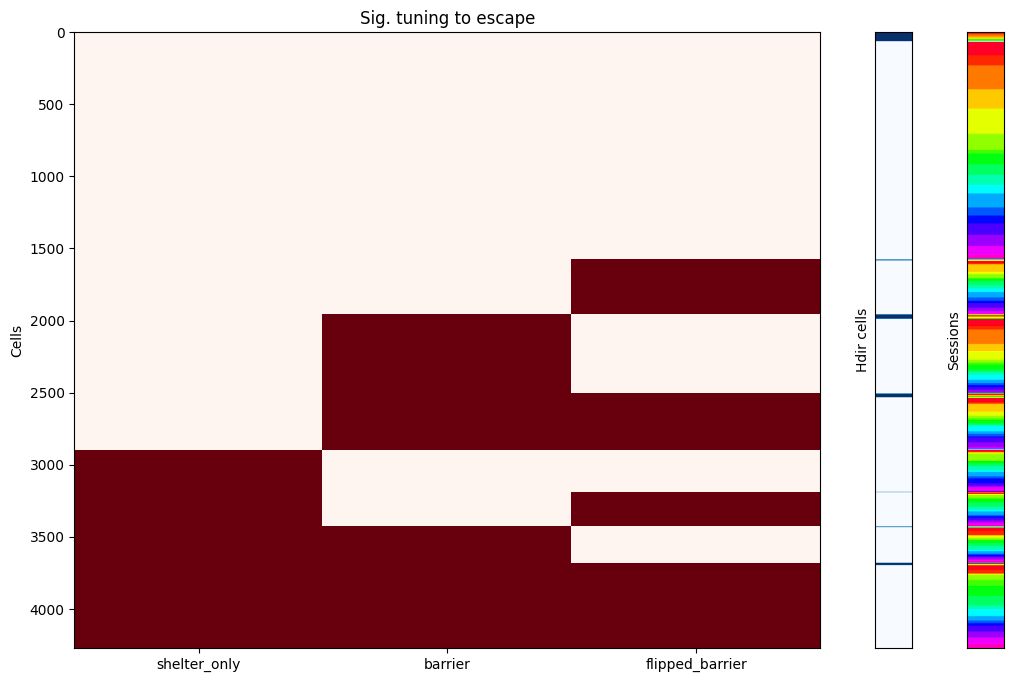

In [124]:
"""Make heatmap sorted by pattern, session and split by hdir"""

comp = 'escape'

# Example nx3 boolean matrix
matrix = sig_cell_dict[comp]

# Define patterns to search for
all_patterns = np.array(list(product([False, True], repeat=3)))

sorted_matrix = []

# Find matching rows
matching_pattern = np.zeros((matrix.shape[0], len(all_patterns)))
for idx, pattern in enumerate(all_patterns):
    cells_in_pattern = np.where((matrix == pattern).all(axis=1))[0]
    matching_pattern[cells_in_pattern, idx] = 1
    # which are the hdir
    hdir_in_pattern = np.logical_and(matching_pattern[:, idx] == 1, all_sesh_hdir == 1)
    non_hdir_in_pattern = np.logical_and(matching_pattern[:, idx] == 1, all_sesh_hdir == 0)
    if idx == 0:
        sorted_matrix = np.vstack((matrix[hdir_in_pattern,:],matrix[non_hdir_in_pattern,:]))
        sorted_hdir = np.hstack((np.ones(np.sum(hdir_in_pattern)), np.zeros(np.sum(non_hdir_in_pattern))))
        sorted_sesh = np.hstack((np.sort(sesh_vector[hdir_in_pattern]), np.sort(sesh_vector[non_hdir_in_pattern])))
    else:
        sorted_matrix = np.vstack((sorted_matrix, matrix[hdir_in_pattern,:],matrix[non_hdir_in_pattern,:]))
        sorted_hdir = np.hstack((sorted_hdir, np.ones(np.sum(hdir_in_pattern)), np.zeros(np.sum(non_hdir_in_pattern))))
        sorted_sesh = np.hstack((sorted_sesh, np.sort(sesh_vector[hdir_in_pattern]), np.sort(sesh_vector[non_hdir_in_pattern])))

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 3, width_ratios=[10, .5, .5])
# Add plots
ax1 = fig.add_subplot(gs[:, 0])  # right column
ax1b = fig.add_subplot(gs[:, 1])  # Spanning both rows
ax1c = fig.add_subplot(gs[:, 2])  # Spanning both rows
ax1.imshow(sorted_matrix, cmap = 'Reds', aspect="auto", interpolation = "none")
ax1.set_ylabel("Cells")
ax1.set_xticks([0,1,2])
ax1.set_xticklabels(c_names)
ax1.set_title('Sig. tuning to ' + comp)

ax1b.imshow(sorted_hdir[:, np.newaxis], cmap = 'Blues', aspect="auto")
ax1b.set_xticks([])  # Hide x-axis ticks
ax1b.set_yticks([])  # Hide y-axis ticks
ax1b.set_ylabel('Hdir cells')

ax1c.imshow(sorted_sesh[:, np.newaxis], cmap = 'gist_rainbow', aspect="auto")
ax1c.set_xticks([])  # Hide x-axis ticks
ax1c.set_yticks([])  # Hide y-axis ticks
ax1c.set_ylabel('Sessions')

plt.show()

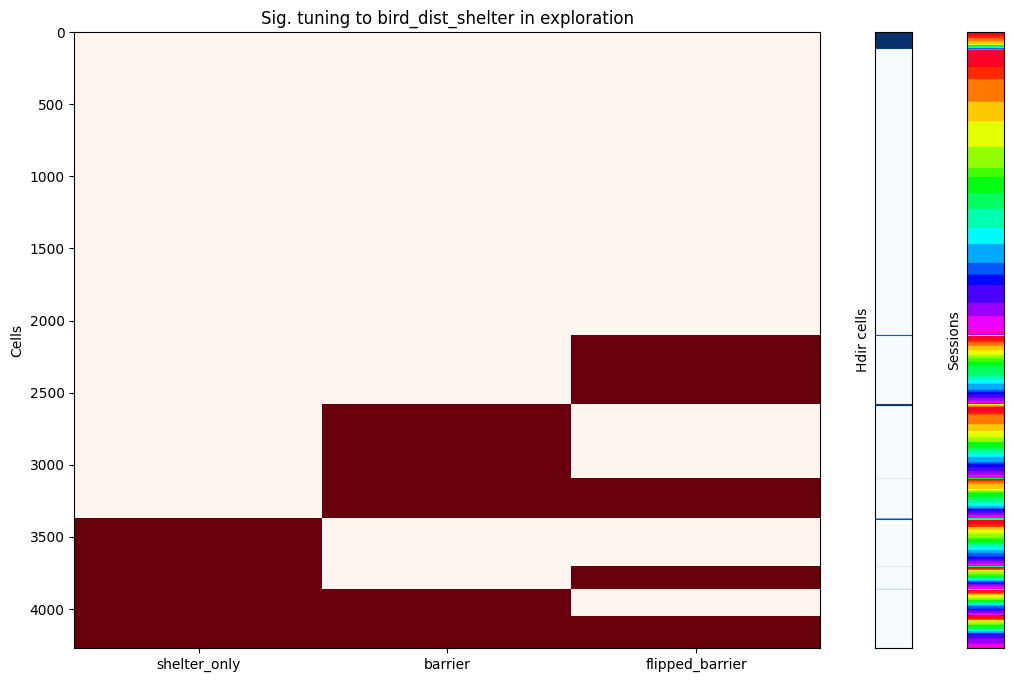

In [125]:
"""Make heatmap of tuning in explore sorted by pattern, session and split by hdir"""

comp = 'bird_dist_shelter'

# Example nx3 boolean matrix
matrix = exp_sig_cell_dict[comp]

# Define patterns to search for
all_patterns = np.array(list(product([False, True], repeat=3)))

sorted_matrix = []

# Find matching rows
matching_pattern = np.zeros((matrix.shape[0], len(all_patterns)))
for idx, pattern in enumerate(all_patterns):
    cells_in_pattern = np.where((matrix == pattern).all(axis=1))[0]
    matching_pattern[cells_in_pattern, idx] = 1
    # which are the hdir
    hdir_in_pattern = np.logical_and(matching_pattern[:, idx] == 1, all_sesh_hdir == 1)
    non_hdir_in_pattern = np.logical_and(matching_pattern[:, idx] == 1, all_sesh_hdir == 0)
    if idx == 0:
        sorted_matrix = np.vstack((matrix[hdir_in_pattern,:],matrix[non_hdir_in_pattern,:]))
        sorted_hdir = np.hstack((np.ones(np.sum(hdir_in_pattern)), np.zeros(np.sum(non_hdir_in_pattern))))
        sorted_sesh = np.hstack((np.sort(sesh_vector[hdir_in_pattern]), np.sort(sesh_vector[non_hdir_in_pattern])))
    else:
        sorted_matrix = np.vstack((sorted_matrix, matrix[hdir_in_pattern,:],matrix[non_hdir_in_pattern,:]))
        sorted_hdir = np.hstack((sorted_hdir, np.ones(np.sum(hdir_in_pattern)), np.zeros(np.sum(non_hdir_in_pattern))))
        sorted_sesh = np.hstack((sorted_sesh, np.sort(sesh_vector[hdir_in_pattern]), np.sort(sesh_vector[non_hdir_in_pattern])))

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 3, width_ratios=[10, .5, .5])
# Add plots
ax1 = fig.add_subplot(gs[:, 0])  # right column
ax1b = fig.add_subplot(gs[:, 1])  # Spanning both rows
ax1c = fig.add_subplot(gs[:, 2])  # Spanning both rows
ax1.imshow(sorted_matrix, cmap = 'Reds', aspect="auto", interpolation = "none")
ax1.set_ylabel("Cells")
ax1.set_xticks([0,1,2])
ax1.set_xticklabels(c_names)
ax1.set_title('Sig. tuning to ' + comp + ' in exploration')

ax1b.imshow(sorted_hdir[:, np.newaxis], cmap = 'Blues', aspect="auto")
ax1b.set_xticks([])  # Hide x-axis ticks
ax1b.set_yticks([])  # Hide y-axis ticks
ax1b.set_ylabel('Hdir cells')

ax1c.imshow(sorted_sesh[:, np.newaxis], cmap = 'gist_rainbow', aspect="auto")
ax1c.set_xticks([])  # Hide x-axis ticks
ax1c.set_yticks([])  # Hide y-axis ticks
ax1c.set_ylabel('Sessions')

plt.show()

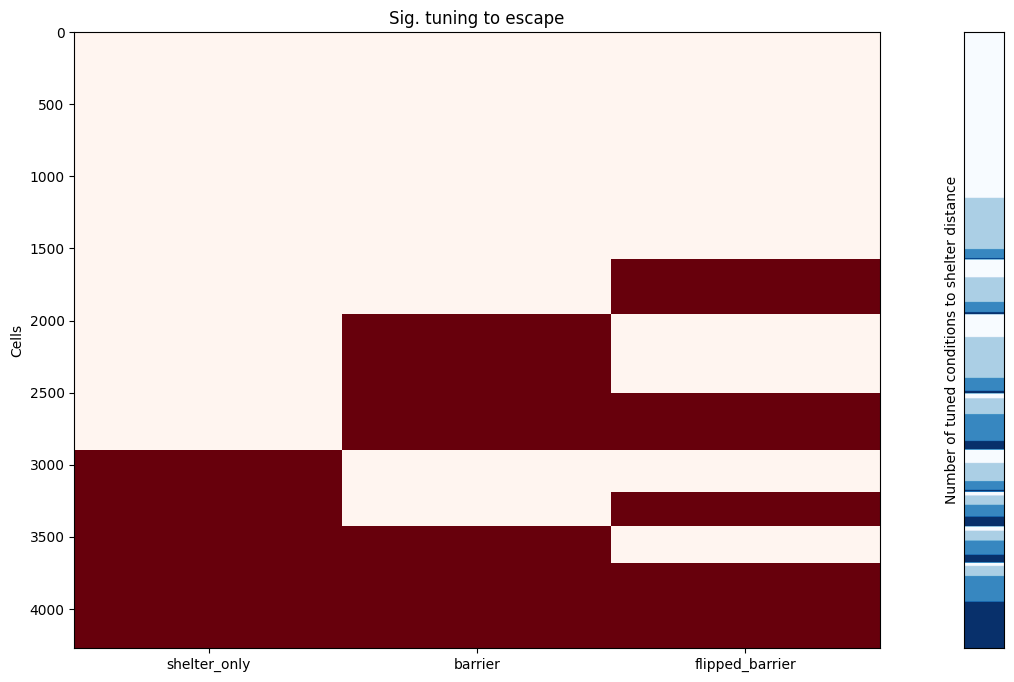

In [122]:
"""Make heatmap sorted by pattern and number of sig. conditions in shelter distance"""

comp = 'escape'

# Example nx3 boolean matrix
matrix = sig_cell_dict[comp]

# Define patterns to search for
all_patterns = np.array(list(product([False, True], repeat=3)))

sorted_matrix = []
bird_dist = np.sum(sig_cell_dict['bird_dist_shelter'], axis = 1)

# Find matching rows
matching_pattern = np.zeros((matrix.shape[0], len(all_patterns)))
for idx, pattern in enumerate(all_patterns):
    cells_in_pattern = np.where((matrix == pattern).all(axis=1))[0]
    matching_pattern[cells_in_pattern, idx] = 1
    if idx == 0:
        sorted_matrix = (matrix[cells_in_pattern,:])
        sorted_bd = np.sort(bird_dist[cells_in_pattern])
    else:
        sorted_matrix = np.vstack((sorted_matrix, matrix[cells_in_pattern,:]))
        sorted_bd = np.hstack((sorted_bd, np.sort(bird_dist[cells_in_pattern])))

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, .5])
# Add plots
ax1 = fig.add_subplot(gs[:, 0])  # right column
ax1b = fig.add_subplot(gs[:, 1])  # Spanning both rows

ax1.imshow(sorted_matrix, cmap = 'Reds', aspect="auto", interpolation = "none")
ax1.set_ylabel("Cells")
ax1.set_xticks([0,1,2])
ax1.set_xticklabels(c_names)
ax1.set_title('Sig. tuning to ' + comp)

ax1b.imshow(sorted_bd[:, np.newaxis], cmap = 'Blues', aspect="auto")
ax1b.set_xticks([])  # Hide x-axis ticks
ax1b.set_yticks([])  # Hide y-axis ticks
ax1b.set_ylabel('Number of tuned conditions to shelter distance')

plt.show()

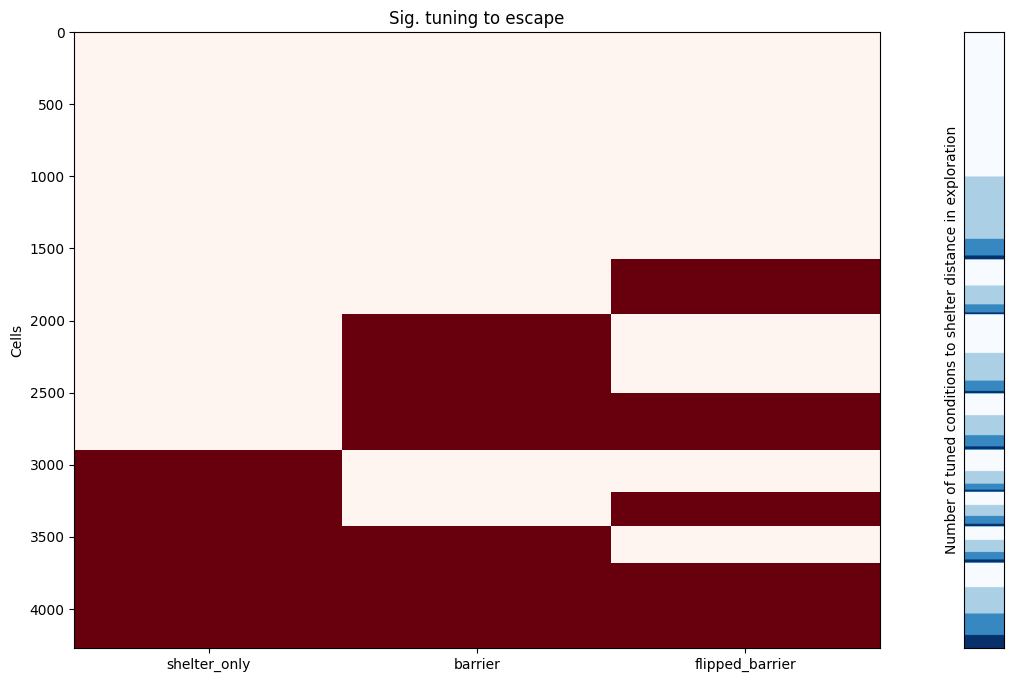

In [127]:
"""Make heatmap sorted by pattern and number of sig. conditions in shelter distance in explore"""

comp = 'escape'

# Example nx3 boolean matrix
matrix = sig_cell_dict[comp]

# Define patterns to search for
all_patterns = np.array(list(product([False, True], repeat=3)))

sorted_matrix = []
bird_dist = np.sum(exp_sig_cell_dict['bird_dist_shelter'], axis = 1)

# Find matching rows
matching_pattern = np.zeros((matrix.shape[0], len(all_patterns)))
for idx, pattern in enumerate(all_patterns):
    cells_in_pattern = np.where((matrix == pattern).all(axis=1))[0]
    matching_pattern[cells_in_pattern, idx] = 1
    if idx == 0:
        sorted_matrix = (matrix[cells_in_pattern,:])
        sorted_bd = np.sort(bird_dist[cells_in_pattern])
    else:
        sorted_matrix = np.vstack((sorted_matrix, matrix[cells_in_pattern,:]))
        sorted_bd = np.hstack((sorted_bd, np.sort(bird_dist[cells_in_pattern])))

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, .5])
# Add plots
ax1 = fig.add_subplot(gs[:, 0])  # right column
ax1b = fig.add_subplot(gs[:, 1])  # Spanning both rows

ax1.imshow(sorted_matrix, cmap = 'Reds', aspect="auto", interpolation = "none")
ax1.set_ylabel("Cells")
ax1.set_xticks([0,1,2])
ax1.set_xticklabels(c_names)
ax1.set_title('Sig. tuning to ' + comp)

ax1b.imshow(sorted_bd[:, np.newaxis], cmap = 'Blues', aspect="auto")
ax1b.set_xticks([])  # Hide x-axis ticks
ax1b.set_yticks([])  # Hide y-axis ticks
ax1b.set_ylabel('Number of tuned conditions to shelter distance in exploration')

plt.show()

old unused cells below

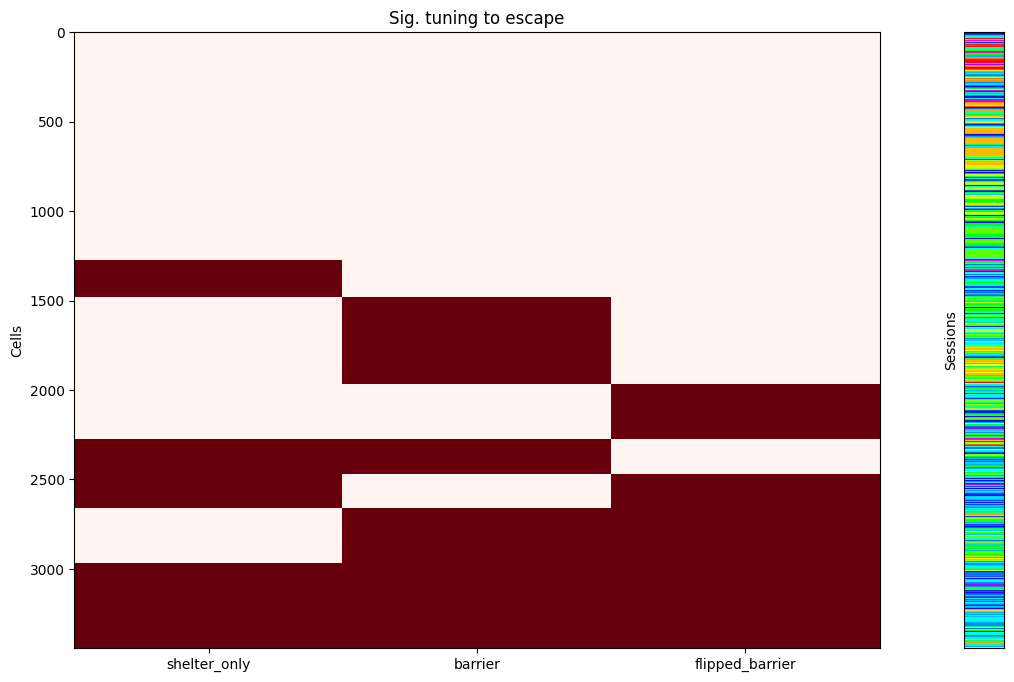

In [7]:
"""Using PCA to sort cells by when they are sig."""
from sklearn.decomposition import PCA

# Convert boolean to integer (0/1)
matrix_int = sig_cell_dict[comp].astype(int)

# Reduce to 1D for sorting
pca = PCA(n_components=1)
reduced = pca.fit_transform(matrix_int)

# Sort by PCA projection
sorted_matrix = matrix_int[np.argsort(reduced[:, 0])]
sorted_vec = sesh_vector[np.argsort(reduced[:, 0])]

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, .5])
# Add plots
ax1 = fig.add_subplot(gs[:, 0])  # right column
ax1b = fig.add_subplot(gs[:, 1])  # Spanning both rows
ax1.imshow(sorted_matrix, cmap = 'Reds', aspect="auto", interpolation = "none")
ax1.set_ylabel("Cells")
ax1.set_xticks([0,1,2])
ax1.set_xticklabels(c_names)
ax1.set_title('Sig. tuning to '+comp)
ax1b.imshow(sorted_vec[:, np.newaxis], cmap = 'gist_rainbow', aspect="auto")
ax1b.set_xticks([])  # Hide x-axis ticks
ax1b.set_yticks([])  # Hide y-axis ticks
ax1b.set_ylabel('Sessions')
plt.show()